In [5]:
import numpy as np
import matplotlib.pyplot as plt

 1. Divided-difference table -> Newton coefficients

In [4]:
def divided_diff_table(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y,dtype=float)
    n = len(x)
    table = np.zeros((n, n))
    table[:, 0] = y
    for j in range(1, n):
        for i in range(n - j):
            table[i, j] = (table[i + 1, j - 1] - table[i, j - 1]) / (x[i + j] - x[i])
    coeffs = table[0, :].copy()
    return table, coeffs

def print_table(x, table):
    n = len(x)
    header = " x " + "".join(f"f[{k}]order".center(14) for k in range(n))
    print(f"{'x':>8} | " + " | ".join(f"order {k}".center(12) for k in range(n)))
    print("-" * (10 + 15 * n))
    for i in range(n):
        row = f"{x[i]:8.4f} | "
        row += " | ".join(f"{table[i, k]:12.6f}" if k <= n - 1 - i else " " * 12
        for k in range(n))
        print(row)

 2. Evaluate the Newton polynomial (nested / Horner-like form)

In [3]:
def newton_eval(coeffs, x_data, x_eval):
    x_eval = np.atleast_1d(np.array(x_eval, dtype=float))
    n = len(coeffs)
    result = np.full_like(x_eval, coeffs[-1])
    for k in range(n - 2, -1, -1):
        result = result * (x_eval - x_data[k]) + coeffs[k]
    return result

3. Simultaneous value + derivative of the Newton polynomial
 (algorithmic recurrence -- NOT symbolic differentiation

In [6]:
def newton_eval_and_deriv(coeffs, x_data, x_eval):
    x_eval = np.atleast_1d(np.array(x_eval, dtype=float))
    n = len(coeffs)
    val = np.full_like(x_eval, coeffs[-1])
    deriv = np.zeros_like(x_eval)
    for k in range(n - 2, -1, -1):
        deriv = deriv * (x_eval - x_data[k]) + val
        val = val * (x_eval - x_data[k]) + coeffs[k]
    return val, deriv

4. Independent Lagrange-form implementation (comparison only)


In [9]:
def lagrange_eval(x_data, y_data, x_eval):
    x_data = np.array(x_data, dtype=float)
    y_data = np.array(y_data, dtype=float)
    x_eval = np.atleast_1d(np.array(x_eval, dtype=float))
    n = len(x_data)
    result = np.zeros_like(x_eval)
    for  i in range(n):
        Li = np.ones_like(x_eval)
        for j in range(n):
            if j != i:
                Li = Li * (x_eval - x_data[j]) / (x_data[i] - x_data[j])
        result = result + y_data[i] * Li
    return result

def lagrange_deriv_eval(x_data, y_data, x_eval):
    x_data = np.array(x_data, dtype=float)
    y_data = np.array(y_data, dtype=float)
    x_eval = np.atleast_1d(np.array(x_eval, dtype=float))
    n = len(x_data)
    deriv = np.zeros_like(x_eval)
    for i in range(n):
        Li = np.ones_like(x_eval)
        for j in range(n):
            if j != i:
                Li = Li * (x_eval - x_data[j]) / (x_data[i] - x_data[j])
                s = np.zeros_like(x_eval)
        for j in range(n):
            if j != i:
                s = s + 1.0 / (x_eval - x_data[j])
                deriv = deriv + y_data[i] * Li * s
        return deriv
    
def central_diff(f, x, h=1e-4):
    x = np.atleast_1d(np.array(x, dtype=float))
    return (f(x + h) - f(x - h)) / (2 * h)
    print("Core Newton / Lagrange interpolation engine loaded.")

In [ ]:
f_q1 = lambda x: x**2 + 2*x + 1

x1 = np.array([-2, -1, 0, 1, 2], dtype=float)
y1 = f_q1(x1)

table1, coeffs1 = divided_diff_table(x1, y1)
print("Divided-difference table:")
print_table(x1, table1)
print("\nNewton coefficients a0..a4:", coeffs1)

x1_eval = [-1.5, -0.5, 0.5, 1.5]
P1_vals = newton_eval(coeffs1, x1, x1_eval)
f1_vals = f_q1(np.array(x1_eval))
err1 = np.abs(f1_vals - P1_vals)

print(f"\n{'x':>6} {'P4(x)':>14} {'f(x)':>14} {'E(x)=|f-P4|':>16}")
for xe, pe, fe, ee in zip(x1_eval, P1_vals, f1_vals, err1):
    print(f"{xe:6.2f} {pe:14.10f} {fe:14.10f} {ee:16.3e}")

Divided-difference table:
       x |   order 0    |   order 1    |   order 2    |   order 3    |   order 4   
-------------------------------------------------------------------------------------
 -2.0000 |     1.000000 |    -1.000000 |     1.000000 |     0.000000 |     0.000000
 -1.0000 |     0.000000 |     1.000000 |     1.000000 |     0.000000 |             
  0.0000 |     1.000000 |     3.000000 |     1.000000 |              |             
  1.0000 |     4.000000 |     5.000000 |              |              |             
  2.0000 |     9.000000 |              |              |              |             

Newton coefficients a0..a4: [ 1. -1.  1.  0.  0.]

     x          P4(x)           f(x)      E(x)=|f-P4|
 -1.50   0.2500000000   0.2500000000        0.000e+00
 -0.50   0.2500000000   0.2500000000        0.000e+00
  0.50   2.2500000000   2.2500000000        0.000e+00
  1.50   6.2500000000   6.2500000000        0.000e+00


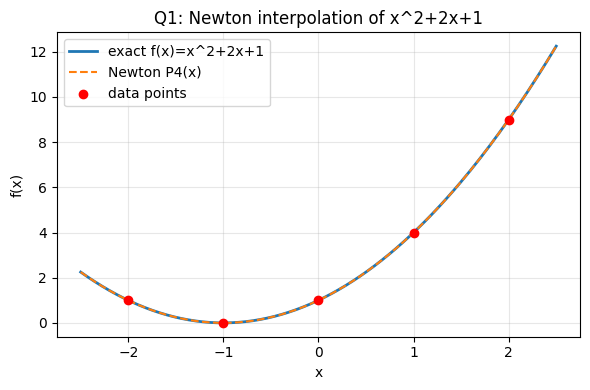

In [11]:
# Quick plot for Q1
xs = np.linspace(-2.5, 2.5, 200)
plt.figure(figsize=(6,4))
plt.plot(xs, f_q1(xs), label="exact f(x)=x^2+2x+1", lw=2)
plt.plot(xs, newton_eval(coeffs1, x1, xs), "--", label="Newton P4(x)")
plt.scatter(x1, y1, color="red", zorder=5, label="data points")
plt.title("Q1: Newton interpolation of x^2+2x+1")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [12]:
x2 = np.array([0, 0.2, 0.55, 1.0, 1.4])
y2 = np.sin(x2)

table2, coeffs2 = divided_diff_table(x2, y2)
print("Divided-difference table:")
print_table(x2, table2)
print("\nNewton coefficients:", coeffs2)

x2_eval = [0.4, 0.8, 1.2]
P2_vals = newton_eval(coeffs2, x2, x2_eval)
f2_vals = np.sin(x2_eval)
err2 = np.abs(f2_vals - P2_vals)

print(f"\n{'x':>6} {'P4(x)':>14} {'sin(x)':>14} {'E(x)':>14}")

for xe, pe, fe, ee in zip(x2_eval, P2_vals, f2_vals, err2):
    print(f"{xe:6.2f} {pe:14.10f} {fe:14.10f} {ee:14.3e}")

Divided-difference table:
       x |   order 0    |   order 1    |   order 2    |   order 3    |   order 4   
-------------------------------------------------------------------------------------
  0.0000 |     0.000000 |     0.993347 |    -0.122875 |    -0.148821 |     0.024004
  0.2000 |     0.198669 |     0.925765 |    -0.271696 |    -0.115215 |             
  0.5500 |     0.522687 |     0.708408 |    -0.409955 |              |             
  1.0000 |     0.841471 |     0.359947 |              |              |             
  1.4000 |     0.985450 |              |              |              |             

Newton coefficients: [ 0.          0.99334665 -0.12287496 -0.14882138  0.02400436]

     x          P4(x)         sin(x)           E(x)
  0.40   0.3894673523   0.3894183423      4.901e-05
  0.80   0.7172626697   0.7173560909      9.342e-05
  1.20   0.9322300290   0.9320390860      1.909e-04
